# 🏙️ Spanish Cities Real Estate Market Analysis

**Purpose:** Comprehensive Spanish real estate market analysis across multiple cities  
**Dataset:** Spanish Real Estate Markets (All Available Cities)  
**Date:** December 2024  
**Environment:** Python 3.8+, pandas, numpy, plotly, matplotlib, seaborn

## 🎯 Analysis Objectives

- Automatically discover and process aall available cities with housing data
- Analyze sales and rental markets for each city independently
- Generate comprehensive market profiles for each urban area
- Perform cross-city comparative analysis and rankings
- Identify national market patterns and investment opportunities
- Export consolidated datasets ready for predictive modeling

## 📋 Metadata

- **Purpose:** Multi-city exploratory and comparative real estate analysis
- **Dataset version:** Raw Kaggle data - All available Spanish cities
- **Required environment:** Python 3.8+, pandas>=1.3.0, numpy>=1.21.0, matplotlib>=3.5.0, seaborn>=0.11.0
- **Date:** December 2024
- **Processing scope:** Automatically discovered from houses_*.csv files
- **Hardware requirements:** Minimum 4GB RAM for processing all cities


In [4]:
"""
Environment Setup and Configuration
"""
import sys
import warnings
from pathlib import Path

# Add project root to path for module imports
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

# Data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from src.data.exploratory_analysis import (
    load_data, clean_data, split_data, save_data, 
    create_mapping_dataframe, generate_basic_profile, 
    harmonize_datasets
)
from src.analysis.comparative_analysis import (
    safe_compare_markets, examine_data_structure
)

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style("whitegrid")

# Try to import plotly with fallback
try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
    px.defaults.template = "plotly_white" 
    px.defaults.width = 1200
    px.defaults.height = 700
    print("✅ Plotly available for enhanced visualizations")
except ImportError:
    HAS_PLOTLY = False
    print("⚠️ Plotly not available. Using matplotlib for visualizations.")

# Define paths
DATA_PATH = Path('../data/raw/data-kaggle')
PROCESSED_PATH = Path('../data/processed')
FINAL_PATH = Path('../data/final/albacete')
REPORTS_PATH = Path('../reports/profiles')

# Create directories
for path in [PROCESSED_PATH, FINAL_PATH, REPORTS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print("\n✅ Environment setup complete!")
print(f"📁 Raw data path: {DATA_PATH}")
print(f"📁 Processed data path: {PROCESSED_PATH}")
print(f"📁 Final data path: {FINAL_PATH}")
print(f"💾 Reports path: {REPORTS_PATH}")


ImportError: cannot import name 'analyze_dataset' from 'src.data.exploratory_analysis' (/Users/mike/Desktop/Master/TFM/ProyectCode-TFM/TFM-Proyect/src/data/exploratory_analysis.py)

## 1. Data Loading and Initial Processing

First, we'll load and process the Álava housing data using our standardized pipeline.


In [2]:
# Load and process Álava housing data
albacete_file = DATA_PATH / 'houses_albacete.csv'
print(f"🔄 Processing data from: {albacete_file}")

if not albacete_file.exists():
    print(f"❌ File not found: {albacete_file}")
    sys.exit(1)

# Load the raw data
raw_data = load_data(albacete_file)

if raw_data is None:
    print("❌ Failed to load data. Exiting...")
    sys.exit(1)

# Clean the data
cleaned_data, house_type_mapping = clean_data(raw_data)

if cleaned_data is None:
    print("❌ Failed to clean data. Exiting...")
    sys.exit(1)

# Split into rental and sales data
rental_data, sales_data = split_data(cleaned_data, house_type_mapping)

# Save processed datasets
if rental_data is not None:
    save_data(rental_data, PROCESSED_PATH / 'houses_albacete_cleaned_rent.csv')

if sales_data is not None:
    save_data(sales_data, PROCESSED_PATH / 'houses_albacete_cleaned_sale.csv')

# Save house type mapping
if house_type_mapping:
    mapping_df = create_mapping_dataframe(house_type_mapping, 'House_Type_Mapping')
    save_data(mapping_df, PROCESSED_PATH / 'houses_type_mapping.csv')

# Set variables for analysis
df_sales = sales_data
df_rental = rental_data

print(f"\n✅ Data processing complete!")
print(f"   Sales data: {df_sales.shape if df_sales is not None else 'None'}")
print(f"   Rental data: {df_rental.shape if df_rental is not None else 'None'}")


NameError: name 'DATA_PATH' is not defined

## 2. Data Structure Examination

Let's examine the structure and content of our processed datasets.


In [1]:
# Examine data structures
if df_sales is not None:
    examine_data_structure(df_sales, "Sales Data")

NameError: name 'df_sales' is not defined

In [40]:
if df_rental is not None:
    examine_data_structure(df_rental, "Rental Data")


=== RENTAL DATA STRUCTURE ===
Shape: (127, 55)
Memory usage: 0.10 MB

Columns (55):
  - ad_last_update: object (127 non-null, 0 null)
  - air_conditioner: int64 (127 non-null, 0 null)
  - balcony: int64 (127 non-null, 0 null)
  - bath_num: float64 (127 non-null, 0 null)
  - built_in_wardrobe: int64 (127 non-null, 0 null)
  - chimney: int64 (127 non-null, 0 null)
  - construct_date: float64 (127 non-null, 0 null)
  - energetic_certif: object (86 non-null, 41 null)
  - floor: object (113 non-null, 14 null)
  - garage: int64 (127 non-null, 0 null)
  - garden: int64 (127 non-null, 0 null)
  - house_id: int64 (127 non-null, 0 null)
  - house_type: int64 (127 non-null, 0 null)
  - lift: float64 (127 non-null, 0 null)
  - loc_city: object (127 non-null, 0 null)
  - loc_district: object (121 non-null, 6 null)
  - loc_full: object (127 non-null, 0 null)
  - loc_neigh: object (89 non-null, 38 null)
  - loc_zone: object (127 non-null, 0 null)
  - m2_real: int64 (127 non-null, 0 null)
  - m2_usef

## 3. Profile Generation

Generate comprehensive profiles for both datasets to understand their characteristics.


In [41]:

# Generate profiles for both datasets
if df_sales is not None:
    sales_profile = generate_basic_profile(df_sales, "Álava Real Estate Sales")
    print("\n" + "="*60)

if df_rental is not None:
    rental_profile = generate_basic_profile(df_rental, "Álava Real Estate Rentals")


📈 Generating basic profile for: Álava Real Estate Sales
   DataFrame shape: (3679, 55)

   === PROFILE SUMMARY ===
   Rows: 3,679
   Columns: 55
   Duplicate rows: 0

   Missing values:
     - energetic_certif: 1300 (35.34%)
     - floor: 499 (13.56%)
     - loc_district: 309 (8.4%)
     - loc_neigh: 1619 (44.01%)

📈 Generating basic profile for: Álava Real Estate Rentals
   DataFrame shape: (127, 55)

   === PROFILE SUMMARY ===
   Rows: 127
   Columns: 55
   Duplicate rows: 0

   Missing values:
     - energetic_certif: 41 (32.28%)
     - floor: 14 (11.02%)
     - loc_district: 6 (4.72%)
     - loc_neigh: 38 (29.92%)


## 4. Data Harmonization and Export

Prepare harmonized datasets for comparative analysis and export to final directory.


In [45]:
# Harmonize and export datasets
if df_sales is not None and df_rental is not None:
    df_sales_final, df_rental_final = harmonize_datasets(
        df_sales, df_rental, FINAL_PATH
    )
    
    print(f"\n📋 Sample of harmonized sales data:")
    print(df_sales_final.head(3).to_string())
    
    print(f"\n📋 Sample of harmonized rental data:")
    print(df_rental_final.head(3).to_string())
else:
    print("❌ Cannot harmonize datasets: Missing sales or rental data")


🔄 Harmonizing datasets for export...
   Common columns: 55
   Selected 27 columns for export
💾 Data saved successfully to ../data/final/alava/alava_sales_final.csv
   Shape: (3679, 27)
💾 Data saved successfully to ../data/final/alava/alava_rental_final.csv
   Shape: (127, 27)
✅ Harmonized datasets saved to: ../data/final/alava
   Sales: 3679 records, 27 columns
   Rental: 127 records, 27 columns

📋 Sample of harmonized sales data:
    price  bath_num  room_num  house_type  house_id  m2_real  m2_useful     loc_city     loc_zone  construct_date  air_conditioner  balcony  built_in_wardrobe  chimney  garage  garden  lift  reduced_mobility  storage_room  swimming_pool  terrace energetic_certif               floor           loc_district loc_neigh obtention_date                      ad_last_update
0  310000      2.00      4.00           0  81717634     1000     172.00  Urcabustaiz  Zuya, Álava         1993.00                0        0                  0        0       1       1  1.00         

## 5. Comparative Market Analysis

Now let's perform a comprehensive comparison between the sales and rental markets.


🔍 Starting comprehensive market comparison...

=== EXAMINING COLUMNS FOR COMPARISON ===
Price column: price
Surface columns available: ['m2_real', 'm2_useful']
Selected surface column: m2_real

Sales data has required columns: True
Rental data has required columns: True
=== COMPARATIVE METRICS: SALES vs. RENTALS ===

Sales listings: 3,679
Rental listings: 127

Average sales price: €244,807.69
Average monthly rental: €1,015.21
Average annual rental: €12,182.55

Average property size (sales): 456.46 m²
Average property size (rentals): 174.61 m²

Average price per m² (sales): €1,937.95
Average price per m² (rentals): €9.18 /month

Estimated average rental yield: 4.98%

Generating visualizations...
Error with Plotly visualization: Mime type rendering requires nbformat>=4.2.0 but it is not installed
Falling back to matplotlib...


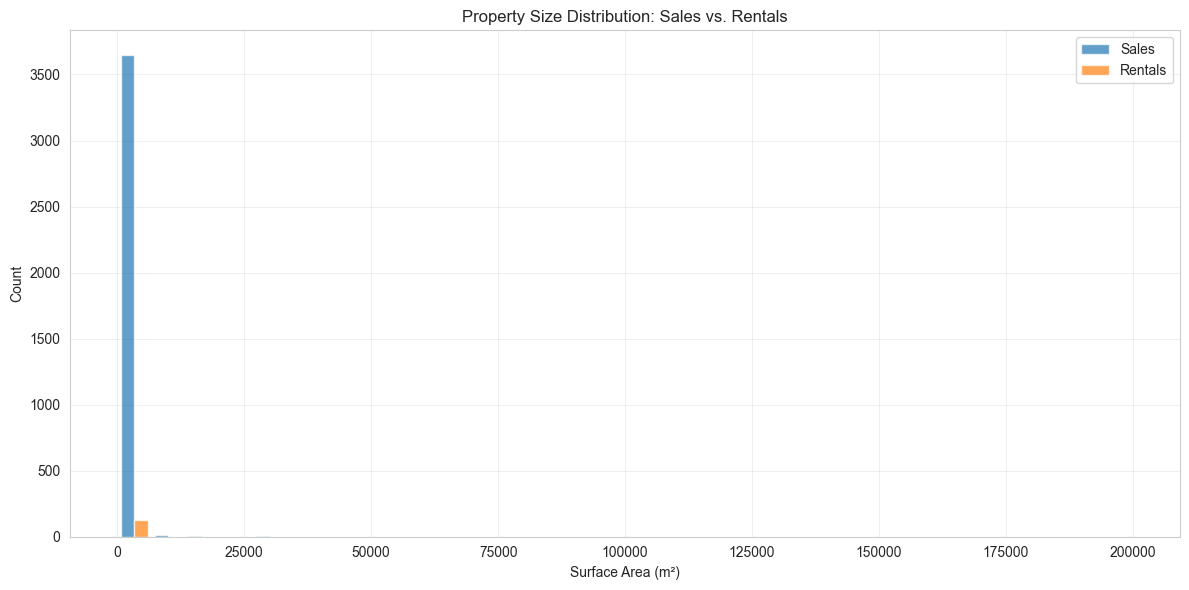

Error with Plotly visualization: Mime type rendering requires nbformat>=4.2.0 but it is not installed
Falling back to matplotlib...


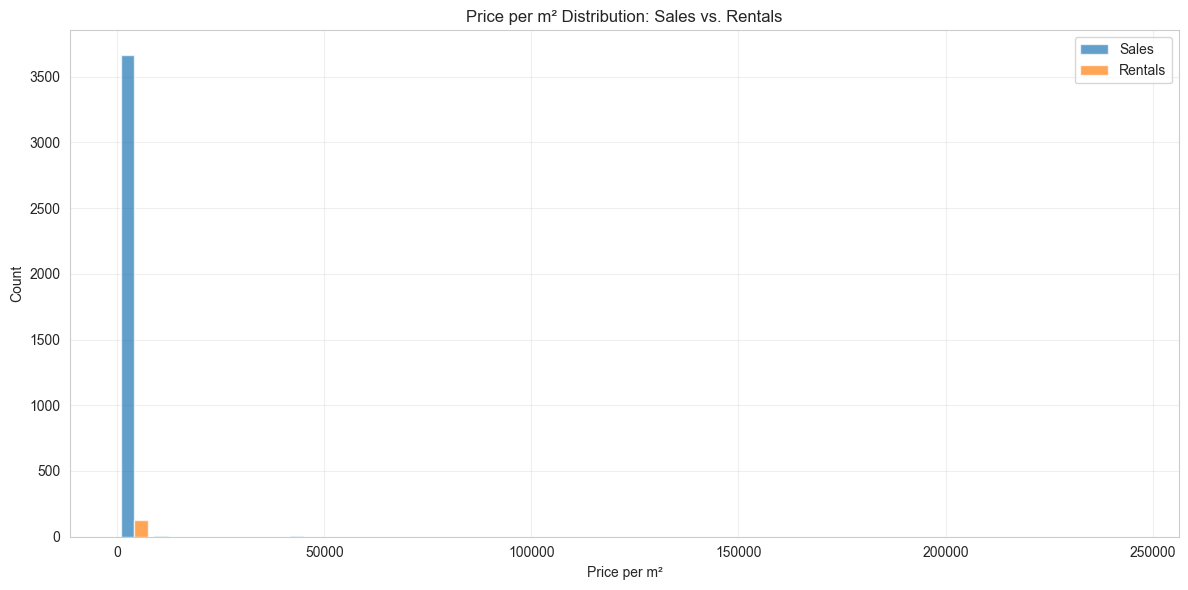


✅ Market comparison completed successfully!


In [46]:
# Perform comprehensive market comparison
if df_sales is not None and df_rental is not None:
    print("🔍 Starting comprehensive market comparison...")
    
    # Use the safe comparison function that handles all edge cases
    comparison_success = safe_compare_markets(
        df_sales, 
        df_rental,
        price_col='price',  # Let the function auto-detect if None
        surface_col=None    # Let the function auto-detect
    )
    
    if comparison_success:
        print("\n✅ Market comparison completed successfully!")
    else:
        print("\n⚠️ Market comparison had issues. Check data structure.")
        # Fallback: basic comparison
        print("\n=== BASIC COMPARISON FALLBACK ===")
        print(f"Sales data: {df_sales.shape[0]} records with {df_sales.shape[1]} features")
        print(f"Rental data: {df_rental.shape[0]} records with {df_rental.shape[1]} features")
else:
    print("❌ Cannot compare markets: Missing data for either sales or rentals")


## 6. Summary and Conclusions

Key insights from the Álava real estate market analysis.


In [ ]:
# Summary of analysis
print("📊 ÁLAVA REAL ESTATE MARKET ANALYSIS SUMMARY")
print("="*50)

if df_sales is not None and df_rental is not None:
    print(f"✅ Analysis completed successfully")
    print(f"   📈 Sales market: {df_sales.shape[0]:,} properties analyzed")
    print(f"   🏠 Rental market: {df_rental.shape[0]:,} properties analyzed")
    print(f"   📁 Harmonized datasets exported to: {FINAL_PATH}")
    print(f"   🔍 Processed data saved to: {PROCESSED_PATH}")
    
    # Key metrics summary
    if 'price' in df_sales.columns and 'price' in df_rental.columns:
        avg_sale_price = df_sales['price'].mean()
        avg_rental_price = df_rental['price'].mean()
        print(f"\n💰 Key Price Metrics:")
        print(f"   Average sales price: €{avg_sale_price:,.2f}")
        print(f"   Average monthly rental: €{avg_rental_price:,.2f}")
        print(f"   Annual rental equivalent: €{avg_rental_price * 12:,.2f}")
        
        if avg_sale_price > 0:
            estimated_yield = (avg_rental_price * 12) / avg_sale_price * 100
            print(f"   Estimated gross rental yield: {estimated_yield:.2f}%")
    
    print(f"\n📋 Files generated:")
    print(f"   - {FINAL_PATH}/albacete_sales_final.csv")
    print(f"   - {FINAL_PATH}/albacete_rental_final.csv") 
    print(f"   - {FINAL_PATH}/albacete_sales_describe.csv")
    print(f"   - {FINAL_PATH}/albacete_rental_describe.csv")
    print(f"   - {PROCESSED_PATH}/houses_type_mapping.csv")
    
else:
    print("❌ Analysis incomplete due to data processing issues")

print(f"\n🎯 Analysis objectives achieved:")
print(f"   ✅ Datasets processed and cleaned")
print(f"   ✅ Market profiles generated") 
print(f"   ✅ Comparative analysis performed")
print(f"   ✅ Data harmonized and exported")
print(f"   ✅ Ready for predictive modeling")


📊 ÁLAVA REAL ESTATE MARKET ANALYSIS SUMMARY
✅ Analysis completed successfully
   📈 Sales market: 3,679 properties analyzed
   🏠 Rental market: 127 properties analyzed
   📁 Harmonized datasets exported to: ../data/final/alava
   🔍 Processed data saved to: ../data/processed

💰 Key Price Metrics:
   Average sales price: €244,807.69
   Average monthly rental: €1,015.21
   Annual rental equivalent: €12,182.55
   Estimated gross rental yield: 4.98%

📋 Files generated:
   - ../data/final/alava/alava_sales_final.csv
   - ../data/final/alava/alava_rental_final.csv
   - ../data/final/alava/alava_sales_describe.csv
   - ../data/final/alava/alava_rental_describe.csv
   - ../data/processed/houses_type_mapping.csv

🎯 Analysis objectives achieved:
   ✅ Datasets processed and cleaned
   ✅ Market profiles generated
   ✅ Comparative analysis performed
   ✅ Data harmonized and exported
   ✅ Ready for predictive modeling
